# Gaze–Hand Text Entry — Analysis

**Team 4 · CS523 · From Late to Early: Gaze–Hand Coordination Errors Through Interaction Learning**

This notebook analyses the data exported by the web prototype. For every
**experiment session** it computes:

* **WPM** (words per minute) and **errors per phrase / accuracy**
* **Early-trigger** vs **late-trigger** coordination errors
* Supporting gaze/hand dynamics for the RQs: **trigger offset**, **fixation
  duration**, **corrective saccades**

and tracks how these change across **Day 1 → Day 2 → Day 3** (the learning
contrast) and how error patterns relate to performance (RQ3).

---
### Data layout this notebook expects
Each day's ZIP unpacks to a run folder:
```
data/<participant>/day_<d>/
├── demographics.json
├── calibration.json
├── experiment_config.json
├── day_summary.csv            # one row per trial (target, typed, CER, duration…)
├── keyboard_layout.csv        # key centres + hit half-extents (viewport px)
├── practice_1/   trial_001_events.csv …   (excluded from analysis)
└── experiment_1/ trial_001_events.csv …   (per-trial unified event log)
```
The **event log** (one CSV per trial) is the substrate for the trigger analysis.
Key `event_type` values:

| event_type        | what it is |
|-------------------|-----------|
| `gaze_sample`     | a continuous gaze reading (`gaze_x/y`, `hovered_key`, `target_char`, `target_key_x/y`) |
| `selection_down`  | Space pressed — a letter is committed; `selected_character` = key under gaze, `target_char` = intended letter |
| `selection_up`    | Space released |
| `trial_start` / `trial_end` | trial boundaries |

> **No correction is allowed in the task** — typed errors are preserved, which is
> exactly what lets us read off coordination errors.


## 0. Setup & configuration

Run this once. If the scientific libraries are missing, uncomment the install line.

In [1]:
# !pip install pandas numpy matplotlib scipy

import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)


In [2]:
# ============================ CONFIG ============================
# Point DATA_ROOT at the folder that CONTAINS the per-participant folders
# (e.g. data/P00/day_1/...). This notebook lives in analysis/, while the data
# folder sits at the repo root, so we resolve it relative to the repo root and
# fall back to a few common spots. We search recursively for day_summary.csv,
# so any folder with the runs somewhere underneath works.
# NOTE: the repo lives under ~/Documents, which is iCloud-synced. iCloud can
# "offload" files (logical size shown, 0 bytes on disk) and a read then triggers
# an on-demand download that may stall with "Errno 60 Operation timed out".
# To avoid that we load from a NON-synced copy in ~/Downloads/data first.
# If you move the data into the repo (or off iCloud), the fallbacks below pick
# it up automatically. You can also just hard-set DATA_ROOT to any path.
def _find_data_root():
    here = Path.cwd()
    candidates = [
        Path.home() / "Downloads" / "data",   # non-iCloud copy (preferred)
        here / "data",                         # running from repo root
        here.parent / "data",                  # running from analysis/
        here / "analysis" / "data",
    ]
    for c in candidates:
        if c.exists() and any(c.rglob("day_summary.csv")):
            return c
    return Path.home() / "Downloads" / "data"

DATA_ROOT = _find_data_root()

# Where aggregated CSVs + figures are written.
OUT_DIR = Path("analysis_output")
OUT_DIR.mkdir(exist_ok=True)

# Which sessions to analyse. Practice / warm-up is excluded per the protocol.
ANALYSE_SESSION_TYPES = ("experiment",)

# ---- WPM ----
# Standard text-entry WPM = (|typed| - 1) / 5 * (60 / seconds).
# "seconds" is measured from the FIRST committed keystroke to the LAST one
# (MacKenzie & Soukoreff convention). CHARS_PER_WORD is fixed at 5 by definition.
CHARS_PER_WORD = 5

# ---- Early/late trigger classifier (see the long markdown below) ----
# Tolerance band (ms) around a trigger within which a selection is treated as
# "on-time" rather than early/late, for the CONTINUOUS offset measure.
ON_TIME_TOL_MS = 80

# Max look-back / look-ahead (ms) when searching the gaze stream for the moment
# the eye was on the target key, relative to a trigger.
GAZE_SEARCH_BEFORE_MS = 1500
GAZE_SEARCH_AFTER_MS = 800

# ---- Fixation detection (I-DT dispersion) ----
FIX_DISPERSION_PX = 60      # max spread of a fixation cluster (viewport px)
FIX_MIN_DURATION_MS = 80    # minimum fixation duration

# Fraction of a fixation's samples that must hover the target key for the
# fixation to count as "on target" (used to time triggers vs. saccades).
ON_TARGET_FRAC = 0.5

print("DATA_ROOT:", DATA_ROOT.resolve())


DATA_ROOT: /Users/yejipark/Downloads/data


## 1. Load all runs

We walk the tree, find every `day_summary.csv`, and load:
* the **trial summary** rows (target/typed/CER/duration), and
* the matching **event-log CSV** for each trial.

Everything is tagged with `participant_id` and `day` so the Day 1→3 contrast is
a simple group-by later.

In [3]:
def _load_json(p: Path):
    try:
        return json.loads(p.read_text())
    except Exception:
        return {}

def discover_runs(root: Path):
    """Yield (run_dir, day_summary_df, config_dict, demographics_dict) per run."""
    summaries = sorted(root.rglob("day_summary.csv"))
    if not summaries:
        print(f"!! No day_summary.csv found under {root.resolve()} — check DATA_ROOT.")
    for sp in summaries:
        run_dir = sp.parent
        df = pd.read_csv(sp)
        cfg = _load_json(run_dir / "experiment_config.json")
        demo = _load_json(run_dir / "demographics.json")
        yield run_dir, df, cfg, demo

runs = list(discover_runs(DATA_ROOT))
print(f"Found {len(runs)} run(s).")
for run_dir, df, cfg, demo in runs:
    pid = df["participant_id"].iloc[0] if len(df) else demo.get("participant_id", "?")
    day = df["day"].iloc[0] if len(df) else demo.get("day", "?")
    n_exp = (df["session_type"] == "experiment").sum()
    print(f"  {run_dir}  |  participant={pid} day={day}  |  {len(df)} trials ({n_exp} experiment)")


Found 7 run(s).
  /Users/yejipark/Downloads/data/P00/day_1  |  participant=P00 day=1  |  60 trials (50 experiment)
  /Users/yejipark/Downloads/data/P00/day_2  |  participant=P00 day=2  |  60 trials (50 experiment)
  /Users/yejipark/Downloads/data/P00/day_3  |  participant=P00 day=3  |  60 trials (50 experiment)
  /Users/yejipark/Downloads/data/P01/day_1  |  participant=P01 day=1  |  60 trials (50 experiment)
  /Users/yejipark/Downloads/data/P01/day_2  |  participant=P01 day=2  |  60 trials (50 experiment)
  /Users/yejipark/Downloads/data/P02/day_1  |  participant=P02 day=1  |  60 trials (50 experiment)
  /Users/yejipark/Downloads/data/P02/day_2  |  participant=P02 day=2  |  60 trials (50 experiment)


In [4]:
# Build the master trial table (one row per trial, all runs concatenated).
trial_frames = []
for run_dir, df, cfg, demo in runs:
    d = df.copy()
    d["run_dir"] = str(run_dir)
    d["participant_id"] = d["participant_id"].astype(str)
    d["day"] = d["day"].astype(str)
    trial_frames.append(d)

trials = pd.concat(trial_frames, ignore_index=True) if trial_frames else pd.DataFrame()
print(f"Total trials loaded: {len(trials)}")
if len(trials):
    display(trials.head())


Total trials loaded: 420


,participant_id,day,session_type,session_index,session_label,trial_id,target_word,typed_text,start_time,end_time,duration_ms,num_characters_typed,target_length,error_count,character_error_rate,event_log_file,run_dir
0,P00,1,practice,1,practice_1,trial_001,later,leotr,1780209480893,1780209504524,23631,5,5,3,0.6,practice_1/trial_001_events.csv,/Users/yejipark/Downloads/data/P00/day_1
1,P00,1,practice,1,practice_1,trial_002,least,leett,1780209504527,1780209555771,51244,5,5,2,0.4,practice_1/trial_002_events.csv,/Users/yejipark/Downloads/data/P00/day_1
2,P00,1,practice,1,practice_1,trial_003,stone,snanr,1780209555777,1780209646060,90283,5,5,3,0.6,practice_1/trial_003_events.csv,/Users/yejipark/Downloads/data/P00/day_1
3,P00,1,practice,1,practice_1,trial_004,learn,lelen,1780209646069,1780209709940,63871,5,5,2,0.4,practice_1/trial_004_events.csv,/Users/yejipark/Downloads/data/P00/day_1
4,P00,1,practice,1,practice_1,trial_005,stare,rsael,1780209709947,1780209761237,51290,5,5,4,0.8,practice_1/trial_005_events.csv,/Users/yejipark/Downloads/data/P00/day_1


In [5]:
# Restrict to the sessions we analyse (experiment only; practice excluded).
analysis_trials = trials[trials["session_type"].isin(ANALYSE_SESSION_TYPES)].copy()
print(f"Trials kept for analysis: {len(analysis_trials)} "
      f"(excluded {len(trials) - len(analysis_trials)} practice/warm-up).")


Trials kept for analysis: 350 (excluded 70 practice/warm-up).


## 2. Per-trial performance: WPM & error per phrase

* **`typed`/`target`** drive accuracy. `error_count` is the Levenshtein distance
  (already computed by the app); `character_error_rate` = errors / target length.
* **WPM** uses the keystroke span from the event log (first → last commit). If
  that is unavailable we fall back to the trial `duration_ms`.
* **errors per phrase** = `error_count` (each trial is one phrase/word).

In [6]:
def load_event_log(run_dir: Path, event_log_file: str) -> pd.DataFrame:
    p = Path(run_dir) / event_log_file
    if not p.exists():
        return pd.DataFrame()
    return pd.read_csv(p)

# Cache event logs so we read each CSV once.
_event_cache: dict = {}
def get_events(row) -> pd.DataFrame:
    key = (row["run_dir"], row["event_log_file"])
    if key not in _event_cache:
        _event_cache[key] = load_event_log(Path(row["run_dir"]), row["event_log_file"])
    return _event_cache[key]


def keystroke_span_seconds(ev: pd.DataFrame):
    """Seconds from first to last committed selection_down (a letter entered)."""
    if ev.empty:
        return None
    sd = ev[(ev["event_type"] == "selection_down") & ev["selected_character"].notna()]
    if len(sd) < 2:
        return None
    t = sd["timestamp"].to_numpy(dtype=float)
    return (t.max() - t.min()) / 1000.0


def compute_wpm(typed: str, span_s, duration_ms):
    typed = "" if (isinstance(typed, float) and math.isnan(typed)) else str(typed)
    n = len(typed)
    if n < 1:
        return np.nan
    # MacKenzie WPM: (|T| - 1) / 5 over the entry time, scaled to 60 s.
    if span_s and span_s > 0:
        secs = span_s
    elif duration_ms and duration_ms > 0:
        secs = duration_ms / 1000.0
    else:
        return np.nan
    return ((n - 1) / CHARS_PER_WORD) * (60.0 / secs)


rows = []
for _, r in analysis_trials.iterrows():
    ev = get_events(r)
    span = keystroke_span_seconds(ev)
    wpm = compute_wpm(r.get("typed_text", ""), span, r.get("duration_ms"))
    rows.append({"wpm": wpm, "entry_seconds": span})

perf = pd.concat([analysis_trials.reset_index(drop=True), pd.DataFrame(rows)], axis=1)
perf["accuracy"] = 1.0 - perf["character_error_rate"].astype(float)
perf["errors_per_phrase"] = perf["error_count"].astype(float)
display(perf[["participant_id", "day", "session_label", "target_word", "typed_text",
              "wpm", "entry_seconds", "error_count", "character_error_rate", "accuracy"]].head(12))


,participant_id,day,session_label,target_word,typed_text,wpm,entry_seconds,error_count,character_error_rate,accuracy
0,P00,1,experiment_1,learn,leaen,2.029255,23.654,1,0.2,0.8
1,P00,1,experiment_1,toast,toast,2.683063,17.890,0,0.0,1.0
2,P00,1,experiment_1,slate,slate,8.465608,5.670,0,0.0,1.0
3,P00,1,experiment_1,snore,snare,2.115563,22.689,1,0.2,0.8
4,P00,1,experiment_1,stone,stone,4.798560,10.003,0,0.0,1.0
5,P00,1,experiment_1,least,least,4.191042,11.453,0,0.0,1.0
6,P00,1,experiment_1,stare,store,5.493877,8.737,1,0.2,0.8
7,P00,1,experiment_1,alone,alane,1.502865,31.939,1,0.2,0.8
8,P00,1,experiment_1,later,lanel,2.974346,16.138,2,0.4,0.6
9,P00,1,experiment_1,alert,alell,1.869814,25.671,2,0.4,0.6


## 3. Early- vs late-trigger classification

### Definitions (from the proposal)
* **Late trigger** — the hand fires *after* the eye has already left the intended
  key (gaze "moved to the next target"). The user looked at the right key, then
  the gaze moved on, and the late pinch lands on a later key.
* **Early trigger** — the hand fires *before* the eye has reached the intended
  key. The pinch lands on a key the gaze is still passing through / hasn't left.

### How we read this off the log
For each `selection_down` event (a committed letter) we know:
* `target_char` — the intended letter, and `target_key_x/y` — its key centre;
* `selected_character` — what was actually entered (the key under gaze at the press);
* the full `gaze_sample` stream, each tagged with `hovered_key` (the key under gaze).

We look at the gaze stream in a window around the trigger and ask **when the eye
was on the target key** relative to the trigger time `t_sel`:

| condition | label |
|-----------|-------|
| eye reached the target key **before** `t_sel` and had **left** it by `t_sel` | **late** |
| eye had **not** reached the target key by `t_sel` (reaches it only after, or not at all) | **early** |
| eye is **on** the target key at `t_sel` | **on-time** |

We report classification two ways:
1. **Among error selections only** (`selected_character != target_char`) → the
   late/early split that RQ1 asks about.
2. A **continuous trigger offset** `t_sel − t_on_target` for *every* selection
   (negative = early, positive = late) → RQ2's hand-trigger timing.

> ⚠️ This is an operational definition built from `hovered_key`. The
> `HOVER_DWELL_MS`/key geometry and the search-window constants above shape it —
> tune them with the team and re-run. Everything downstream reads from the
> `selections` table this section produces.

In [7]:
def detect_fixation_intervals(gz: pd.DataFrame):
    """I-DT dispersion fixation detector returning the fixation INTERVALS.

    Returns (g, intervals) where `g` is the cleaned/sorted gaze frame and
    `intervals` is a list of (t_start, t_end, i0, i1) — t_start/t_end in the
    same time unit as `timestamp` (ms), and [i0, i1) the row slice into `g`.
    A fixation onset is the end of the saccade landing on that location; the
    fixation offset (t_end) is the onset of the saccade leaving it. These edges
    are what we time the trigger against (cf. late-trigger errors, ETRA 2025).
    """
    g = gz.dropna(subset=["gaze_x", "gaze_y"]).sort_values("timestamp").reset_index(drop=True)
    xs = g["gaze_x"].to_numpy(dtype=float)
    ys = g["gaze_y"].to_numpy(dtype=float)
    ts = g["timestamp"].to_numpy(dtype=float)
    n = len(ts)
    intervals = []
    i = 0
    while i < n:
        j = i + 1
        while j < n:
            disp = (xs[i:j+1].max() - xs[i:j+1].min()) + (ys[i:j+1].max() - ys[i:j+1].min())
            if disp > FIX_DISPERSION_PX:
                break
            j += 1
        dur = ts[j-1] - ts[i]
        if dur >= FIX_MIN_DURATION_MS and (j - i) >= 2:
            intervals.append((ts[i], ts[j-1], i, j))
            i = j
        else:
            i += 1
    return g, intervals


def classify_selection(ev: pd.DataFrame, sel_row, prev_sel_t, next_sel_t):
    """Classify one selection_down using the gaze stream `ev` (whole trial).

    Returns dict with: error(bool), label(early/late/on_time/no_target_fix),
    offset_ms (signed continuous = t_sel - gaze-leaves-target; <0 in time, >0 late),
    dist_px (gaze-to-target at trigger).

    Timing is FIXATION-based: we detect the fixation that settled on the target
    key (>= ON_TARGET_FRAC of its samples hovering the target) and time the
    trigger against that fixation's onset (saccade arrival) and offset (saccade
    departure). This is the saccade-relative measure the late-trigger analysis
    needs, instead of raw hover min/max. Falls back to hover timestamps only when
    no qualifying fixation exists (brief glance, no stable dwell).
    """
    t_sel = float(sel_row["timestamp"])
    target = sel_row.get("target_char")
    selected = sel_row.get("selected_character")
    is_error = (pd.notna(target)) and (str(selected) != str(target))

    gz = ev[ev["event_type"] == "gaze_sample"].copy()
    # Window: bounded by neighbouring selections, then clipped to a max span so a
    # long pause before the trial doesn't leak in.
    lo = max(prev_sel_t if prev_sel_t is not None else t_sel - GAZE_SEARCH_BEFORE_MS,
             t_sel - GAZE_SEARCH_BEFORE_MS)
    hi = min(next_sel_t if next_sel_t is not None else t_sel + GAZE_SEARCH_AFTER_MS,
             t_sel + GAZE_SEARCH_AFTER_MS)
    gz = gz[(gz["timestamp"] >= lo) & (gz["timestamp"] <= hi)]

    # Distance from gaze to the target key at the trigger (spatial sanity signal).
    dist_px = np.nan
    if pd.notna(sel_row.get("gaze_x")) and pd.notna(sel_row.get("target_key_x")):
        dist_px = math.hypot(float(sel_row["gaze_x"]) - float(sel_row["target_key_x"]),
                             float(sel_row["gaze_y"]) - float(sel_row["target_key_y"]))

    if pd.isna(target) or gz.empty:
        return {"is_error": bool(is_error), "label": "no_target_fix",
                "offset_ms": np.nan, "dist_px": dist_px}

    # --- Fixation onset/offset on the target (saccade-relative timing) ---
    g, intervals = detect_fixation_intervals(gz)
    t_enter = t_leave = None
    if intervals:
        hk = g["hovered_key"].astype("object").to_numpy()
        on_target = []
        for (t0, t1, i0, i1) in intervals:
            frac = np.mean(hk[i0:i1] == target) if i1 > i0 else 0.0
            if frac >= ON_TARGET_FRAC:
                on_target.append((t0, t1))
        if on_target:
            # Pick the target fixation temporally closest to the trigger: 0 gap if
            # the trigger falls inside it, else distance to the nearest edge. This
            # naturally selects the upcoming fixation for early triggers and the
            # preceding one for late triggers.
            def _gap(tf):
                a, b = tf
                if t_sel < a:
                    return a - t_sel
                if t_sel > b:
                    return t_sel - b
                return 0.0
            t_enter, t_leave = min(on_target, key=_gap)

    # Fallback: no stable fixation on target -> use hover timestamps (legacy path).
    if t_enter is None:
        on_t = gz[gz["hovered_key"].astype("object") == target]["timestamp"].to_numpy(dtype=float)
        if on_t.size == 0:
            # Eye never settled on the target in the window. If a wrong key was
            # committed the eye was passing through something else -> early.
            return {"is_error": bool(is_error), "label": "early",
                    "offset_ms": np.nan, "dist_px": dist_px}
        t_enter, t_leave = on_t.min(), on_t.max()

    # Categorical label (RQ1): trigger position vs. the target fixation, with a
    # tolerance band so triggers inside the dwell count as on-time.
    if t_sel < t_enter - ON_TIME_TOL_MS:
        label = "early"          # fired before gaze arrived
    elif t_sel > t_leave + ON_TIME_TOL_MS:
        label = "late"           # fired after gaze left
    else:
        label = "on_time"
    # Continuous offset (RQ2) computed for EVERY selection, not just mistimed
    # ones: trigger time relative to the moment gaze leaves the target fixation
    # (saccade departure). This is the late-trigger latency axis.
    #   < 0  fired while still on / before reaching the target  (in time)
    #     0  fired exactly as the eye saccades away
    #   > 0  fired after the eye had already left the target     (late)
    offset = t_sel - t_leave
    return {"is_error": bool(is_error), "label": label,
            "offset_ms": float(offset), "dist_px": dist_px}


sel_records = []
for _, r in analysis_trials.iterrows():
    ev = get_events(r)
    if ev.empty:
        continue
    sels = ev[(ev["event_type"] == "selection_down") & ev["selected_character"].notna()]
    sels = sels.sort_values("timestamp").reset_index(drop=True)
    sel_t = sels["timestamp"].to_numpy(dtype=float)
    for i, (_, s) in enumerate(sels.iterrows()):
        prev_t = sel_t[i - 1] if i > 0 else None
        next_t = sel_t[i + 1] if i + 1 < len(sel_t) else None
        c = classify_selection(ev, s, prev_t, next_t)
        sel_records.append({
            "participant_id": r["participant_id"], "day": r["day"],
            "session_label": r["session_label"], "trial_id": r["trial_id"],
            "input_index": s.get("input_index"),
            "target_char": s.get("target_char"), "selected_character": s.get("selected_character"),
            **c,
        })

selections = pd.DataFrame(sel_records)
print(f"Total committed selections analysed: {len(selections)}")
if len(selections):
    print(selections["label"].value_counts())
    display(selections.head(12))


Total committed selections analysed: 1750
label
on_time    1138
late        487
early       125
Name: count, dtype: int64


,participant_id,day,session_label,trial_id,input_index,target_char,selected_character,is_error,label,offset_ms,dist_px
0,P00,1,experiment_1,trial_001,1.0,l,l,False,late,119.0,107.267362
1,P00,1,experiment_1,trial_001,2.0,e,e,False,late,99.0,306.933517
2,P00,1,experiment_1,trial_001,3.0,a,a,False,on_time,53.0,227.209403
3,P00,1,experiment_1,trial_001,4.0,r,e,True,on_time,-51.0,210.054366
4,P00,1,experiment_1,trial_001,5.0,n,n,False,late,283.0,359.052760
5,P00,1,experiment_1,trial_002,1.0,t,t,False,early,-298.0,453.444581
6,P00,1,experiment_1,trial_002,2.0,o,o,False,late,199.0,144.928109
7,P00,1,experiment_1,trial_002,3.0,a,a,False,on_time,-52.0,185.778537
8,P00,1,experiment_1,trial_002,4.0,s,s,False,late,133.0,255.792586
9,P00,1,experiment_1,trial_002,5.0,t,t,False,on_time,-85.0,177.626056


In [8]:
# Error-only late/early split (RQ1).
errors = selections[selections["is_error"]].copy()
print(f"Error selections: {len(errors)} of {len(selections)} "
      f"({100*len(errors)/max(len(selections),1):.1f}%)")
if len(errors):
    print("\nError-trigger type counts:")
    print(errors["label"].value_counts())


Error selections: 214 of 1750 (12.2%)

Error-trigger type counts:
label
on_time    92
late       88
early      34
Name: count, dtype: int64


## 4. Fixation duration & corrective saccades (RQ2)

* **Fixation duration** — a dispersion-based (I-DT) detector groups consecutive
  gaze samples whose spread stays under `FIX_DISPERSION_PX` for at least
  `FIX_MIN_DURATION_MS`. We report the mean fixation duration per session.
* **Corrective saccades (proxy)** — per committed letter, how many times the
  gaze *re-enters* the target key after first leaving it before the commit. A
  clean, confident selection has 0; hunting/correcting raises it.

Both are approximate (webcam gaze is noisy) — treat as proxies and tune the
thresholds with the team.

In [9]:
def detect_fixations(gz: pd.DataFrame):
    """I-DT dispersion fixation detector. Returns list of durations (ms).

    Thin wrapper over detect_fixation_intervals so the duration- and
    interval-based callers share one detector.
    """
    _, intervals = detect_fixation_intervals(gz)
    return [t1 - t0 for (t0, t1, _i0, _i1) in intervals]


def corrective_saccades_for_trial(ev: pd.DataFrame):
    """Per committed letter, count re-entries to the target key before commit."""
    gz = ev[ev["event_type"] == "gaze_sample"].sort_values("timestamp")
    sels = ev[(ev["event_type"] == "selection_down") & ev["selected_character"].notna()]
    sels = sels.sort_values("timestamp")
    sel_t = sels["timestamp"].to_numpy(dtype=float)
    counts = []
    for i, (_, s) in enumerate(sels.iterrows()):
        t_sel = float(s["timestamp"])
        lo = sel_t[i-1] if i > 0 else (t_sel - GAZE_SEARCH_BEFORE_MS)
        seg = gz[(gz["timestamp"] >= lo) & (gz["timestamp"] <= t_sel)]
        target = s.get("target_char")
        if pd.isna(target) or seg.empty:
            continue
        on = (seg["hovered_key"].astype("object") == target).to_numpy()
        # number of rising edges (off->on) beyond the first arrival = re-entries
        entries = int(np.sum((~on[:-1]) & on[1:])) if on.size > 1 else int(on[:1].sum())
        counts.append(max(entries - 1, 0))
    return counts


fix_records = []
for _, r in analysis_trials.iterrows():
    ev = get_events(r)
    if ev.empty:
        continue
    gz = ev[ev["event_type"] == "gaze_sample"]
    durs = detect_fixations(gz)
    corr = corrective_saccades_for_trial(ev)
    fix_records.append({
        "participant_id": r["participant_id"], "day": r["day"],
        "session_label": r["session_label"], "trial_id": r["trial_id"],
        "mean_fixation_ms": np.mean(durs) if durs else np.nan,
        "n_fixations": len(durs),
        "mean_corrective_saccades": np.mean(corr) if corr else np.nan,
    })

trial_gaze = pd.DataFrame(fix_records)
if len(trial_gaze):
    display(trial_gaze.head())


,participant_id,day,session_label,trial_id,mean_fixation_ms,n_fixations,mean_corrective_saccades
0,P00,1,experiment_1,trial_001,109.426471,68,5.8
1,P00,1,experiment_1,trial_002,101.358974,39,5.4
2,P00,1,experiment_1,trial_003,98.823529,17,1.8
3,P00,1,experiment_1,trial_004,99.371429,35,2.6
4,P00,1,experiment_1,trial_005,99.000000,12,1.2


## 5. Aggregate per session & per day

Roll everything up to **(participant, day, session)** and **(participant, day)**.
The per-day table is what drives the learning-curve figures and RQ3 correlations.

In [10]:
# --- selection-derived rates per (participant, day, session) ---
# Built with an explicit loop (rather than groupby.apply) so it behaves the same
# across pandas versions and never operates on the grouping columns.
def sel_rates(g):
    n = len(g)
    n_err = int(g["is_error"].sum())
    n_late = int(((g["label"] == "late") & g["is_error"]).sum())
    n_early = int(((g["label"] == "early") & g["is_error"]).sum())
    return {
        "n_selections": n,
        "n_errors": n_err,
        "error_rate_per_keystroke": n_err / n if n else np.nan,
        "n_late_err": n_late,
        "n_early_err": n_early,
        "late_share_of_err": n_late / n_err if n_err else np.nan,
        "early_share_of_err": n_early / n_err if n_err else np.nan,
        "mean_trigger_offset_ms": g["offset_ms"].mean(skipna=True),
        "median_trigger_offset_ms": g["offset_ms"].median(skipna=True),
    }

if len(selections):
    _recs = []
    for (pid, day, sl), g in selections.groupby(["participant_id", "day", "session_label"]):
        _recs.append({"participant_id": pid, "day": day, "session_label": sl, **sel_rates(g)})
    sel_by_session = pd.DataFrame(_recs)
else:
    sel_by_session = pd.DataFrame()

# --- performance per (participant, day, session) ---
perf_by_session = (perf.groupby(["participant_id", "day", "session_label"])
                   .agg(mean_wpm=("wpm", "mean"),
                        mean_errors_per_phrase=("errors_per_phrase", "mean"),
                        mean_cer=("character_error_rate", "mean"),
                        mean_accuracy=("accuracy", "mean"),
                        n_trials=("trial_id", "count"))
                   .reset_index())

# --- gaze dynamics per session ---
gaze_by_session = (trial_gaze.groupby(["participant_id", "day", "session_label"])
                   .agg(mean_fixation_ms=("mean_fixation_ms", "mean"),
                        mean_corrective_saccades=("mean_corrective_saccades", "mean"))
                   .reset_index()) if len(trial_gaze) else pd.DataFrame()

session_metrics = perf_by_session
for extra in (sel_by_session, gaze_by_session):
    if len(extra):
        session_metrics = session_metrics.merge(
            extra, on=["participant_id", "day", "session_label"], how="left")

session_metrics = session_metrics.sort_values(["participant_id", "day", "session_label"])
display(session_metrics)


,participant_id,day,session_label,mean_wpm,mean_errors_per_phrase,mean_cer,mean_accuracy,n_trials,n_selections,n_errors,error_rate_per_keystroke,n_late_err,n_early_err,late_share_of_err,early_share_of_err,mean_trigger_offset_ms,median_trigger_offset_ms,mean_fixation_ms,mean_corrective_saccades
0,P00,1,experiment_1,3.612399,0.8,0.16,0.84,10,50,8,0.16,2,2,0.250000,0.250000,28.708333,9.5,100.423793,2.96
1,P00,1,experiment_2,6.788689,1.2,0.24,0.76,10,50,12,0.24,4,4,0.333333,0.333333,20.877551,-47.0,98.959102,2.04
2,P00,1,experiment_3,7.282438,0.5,0.10,0.90,10,50,5,0.10,2,1,0.400000,0.200000,27.860000,1.0,103.390525,1.80
3,P00,1,experiment_4,6.544766,1.0,0.20,0.80,10,50,11,0.22,3,2,0.272727,0.181818,21.270833,-31.5,101.337839,2.16
4,P00,1,experiment_5,6.839857,1.1,0.22,0.78,10,50,11,0.22,3,1,0.272727,0.090909,-5.040000,-48.0,99.470883,2.12
5,P00,2,experiment_1,9.147760,0.9,0.18,0.82,10,50,9,0.18,7,0,0.777778,0.000000,65.200000,1.0,98.759658,1.74
6,P00,2,experiment_2,9.036828,0.5,0.10,0.90,10,50,5,0.10,3,0,0.600000,0.000000,55.680000,10.0,99.318935,0.98
7,P00,2,experiment_3,8.879099,0.7,0.14,0.86,10,50,7,0.14,3,2,0.428571,0.285714,-4.640000,-23.5,103.768873,1.60
8,P00,2,experiment_4,7.405710,1.2,0.24,0.76,10,50,12,0.24,5,4,0.416667,0.333333,-16.400000,-31.0,103.564018,1.76
9,P00,2,experiment_5,7.316420,0.7,0.14,0.86,10,50,7,0.14,4,2,0.571429,0.285714,12.080000,1.0,106.163103,1.66


In [11]:
# --- per (participant, day): the learning-contrast unit ---
agg_cols = {c: "mean" for c in session_metrics.columns
            if c not in ("participant_id", "day", "session_label", "n_trials", "n_selections",
                          "n_errors", "n_late_err", "n_early_err")}
day_metrics = (session_metrics.groupby(["participant_id", "day"])
               .agg(agg_cols).reset_index()
               .sort_values(["participant_id", "day"]))
display(day_metrics)

# Group means across participants, by day (for the headline learning curves).
by_day = day_metrics.groupby("day").mean(numeric_only=True).reset_index()
display(by_day)


,participant_id,day,mean_wpm,mean_errors_per_phrase,mean_cer,mean_accuracy,error_rate_per_keystroke,late_share_of_err,early_share_of_err,mean_trigger_offset_ms,median_trigger_offset_ms,mean_fixation_ms,mean_corrective_saccades
0,P00,1,6.213630,0.92,0.184,0.816,0.188,0.305758,0.211212,18.735344,-23.2,100.716428,2.216
1,P00,2,8.357163,0.80,0.160,0.840,0.160,0.558889,0.180952,22.384000,-8.5,102.314917,1.548
2,P00,3,7.476298,0.80,0.160,0.840,0.172,0.516014,0.207366,65.471833,21.4,102.525283,2.324
3,P01,1,6.691228,0.48,0.096,0.904,0.096,0.481905,0.028571,-66.180000,-62.6,94.873684,2.880
4,P01,2,9.014455,0.48,0.096,0.904,0.096,0.483929,0.000000,-41.988000,-54.8,93.563723,1.660
5,P02,1,6.673462,0.58,0.116,0.884,0.116,0.257143,0.050000,-82.824000,-92.0,91.999253,2.652
6,P02,2,10.739680,0.14,0.028,0.972,0.028,0.083333,0.541667,-54.106531,-52.6,99.383491,0.712


,day,mean_wpm,mean_errors_per_phrase,mean_cer,mean_accuracy,error_rate_per_keystroke,late_share_of_err,early_share_of_err,mean_trigger_offset_ms,median_trigger_offset_ms,mean_fixation_ms,mean_corrective_saccades
0,1,6.526107,0.660000,0.132000,0.868000,0.133333,0.348268,0.096595,-43.422885,-59.266667,95.863122,2.582667
1,2,9.370433,0.473333,0.094667,0.905333,0.094667,0.375384,0.240873,-24.570177,-38.633333,98.420711,1.306667
2,3,7.476298,0.800000,0.160000,0.840000,0.172000,0.516014,0.207366,65.471833,21.400000,102.525283,2.324000


## 6. Figures — learning curves & error-pattern shift

* **WPM / accuracy / error rate** vs day — per participant (thin) + mean (bold).
* **Early vs late share** of errors by day — the RQ1 headline.

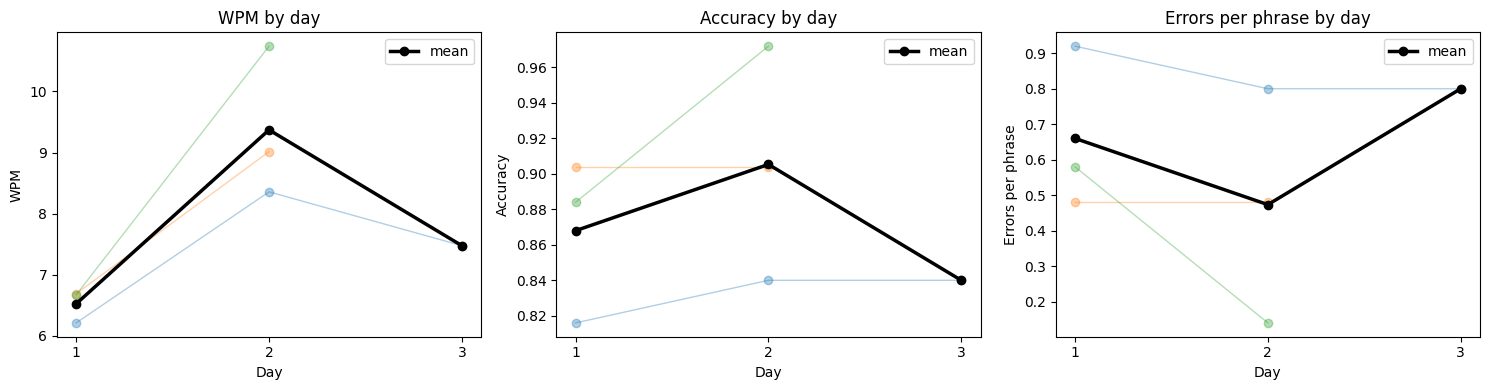

In [12]:
def learning_curve(metric, ylabel, ax):
    for pid, g in day_metrics.groupby("participant_id"):
        g = g.sort_values("day")
        ax.plot(g["day"], g[metric], marker="o", alpha=0.35, linewidth=1)
    m = day_metrics.groupby("day")[metric].mean()
    ax.plot(m.index, m.values, marker="o", color="black", linewidth=2.5, label="mean")
    ax.set_xlabel("Day"); ax.set_ylabel(ylabel); ax.set_title(ylabel + " by day")
    ax.legend()

curves = [("mean_wpm", "WPM"),
          ("mean_accuracy", "Accuracy"),
          ("mean_errors_per_phrase", "Errors per phrase")]
curves = [(m, l) for m, l in curves if m in day_metrics.columns]
if curves and len(day_metrics):
    fig, axes = plt.subplots(1, len(curves), figsize=(5 * len(curves), 4))
    if len(curves) == 1:
        axes = [axes]
    for (m, l), ax in zip(curves, axes):
        learning_curve(m, l, ax)
    plt.tight_layout(); plt.savefig(OUT_DIR / "learning_curves.png", dpi=150); plt.show()
else:
    print("Not enough data for learning curves yet.")


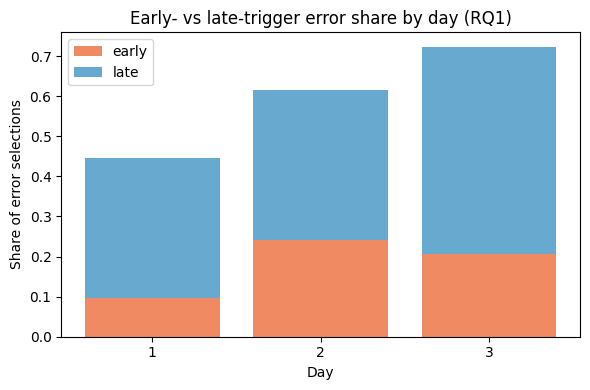

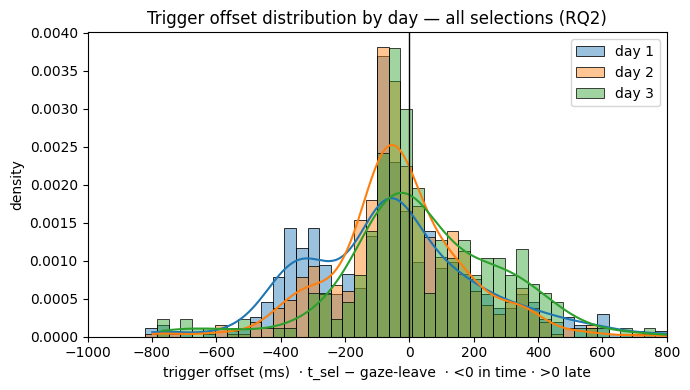

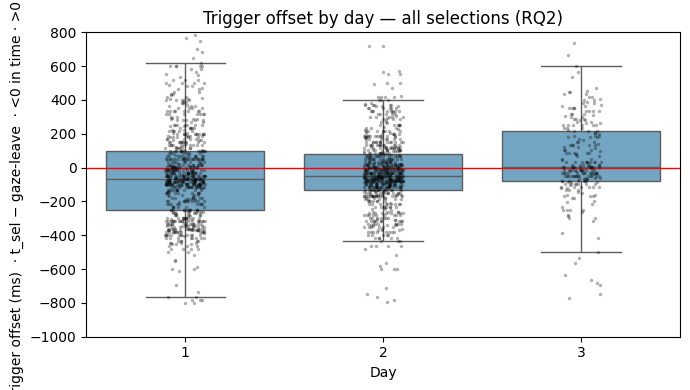

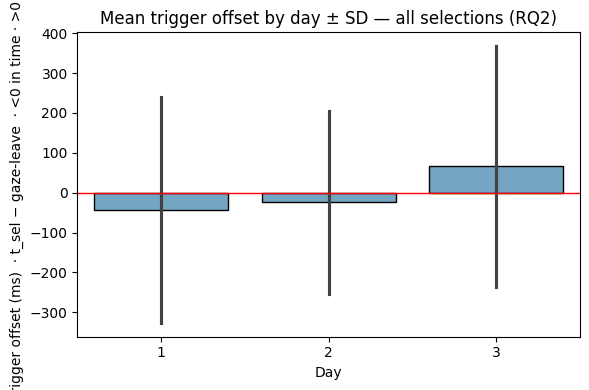

In [13]:
# Early vs late share of errors, by day (stacked).
import seaborn as sns
if len(day_metrics) and "late_share_of_err" in day_metrics.columns:
    md_ = day_metrics.groupby("day")[["early_share_of_err", "late_share_of_err"]].mean()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(md_.index, md_["early_share_of_err"], label="early", color="#ef8a62")
    ax.bar(md_.index, md_["late_share_of_err"], bottom=md_["early_share_of_err"],
           label="late", color="#67a9cf")
    ax.set_xlabel("Day"); ax.set_ylabel("Share of error selections")
    ax.set_title("Early- vs late-trigger error share by day (RQ1)")
    ax.legend(); plt.tight_layout()
    plt.savefig(OUT_DIR / "early_late_by_day.png", dpi=150); plt.show()

    # ---- RQ2: continuous trigger offset over ALL selections ----
    # offset_ms = t_sel - (gaze leaves target).  <0 in time, >0 late.
    XLAB = "trigger offset (ms)  \u00b7 t_sel \u2212 gaze-leave  \u00b7 <0 in time \u00b7 >0 late"
    off = selections.dropna(subset=["offset_ms"])

    # Distribution by day (histogram, all selections).
    fig, ax = plt.subplots(figsize=(7, 4))
    for day, g in off.groupby("day"):
        sns.histplot(g["offset_ms"], ax=ax, bins=50, alpha=0.45,
                    stat="density", kde=True, label=f"day {day}",
                    binrange=(-1000, 800))
    ax.axvline(0, color="k", lw=1)
    ax.set_xlabel(XLAB); ax.set_ylabel("density")
    ax.set_title("Trigger offset distribution by day \u2014 all selections (RQ2)")
    ax.set_xlim(-1000, 800)
    ax.legend(); plt.tight_layout()
    plt.savefig(OUT_DIR / "trigger_offset_hist_by_day.png", dpi=150); plt.show()

    # Box plot by day (all selections) \u2014 full distribution incl. on-time.
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.boxplot(data=off, x="day", y="offset_ms", ax=ax,
                showfliers=False, color="#67a9cf")
    sns.stripplot(data=off, x="day", y="offset_ms", ax=ax,
                  size=2.5, alpha=0.30, color="k")
    ax.axhline(0, color="r", lw=1)
    ax.set_xlabel("Day"); ax.set_ylabel(XLAB)
    ax.set_title("Trigger offset by day \u2014 all selections (RQ2)")
    ax.set_ylim(-1000, 800)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "trigger_offset_box_by_day.png", dpi=150); plt.show()

    # Mean \u00b1 SD by day (all selections).
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(data=off, x="day", y="offset_ms", ax=ax, estimator=np.mean,
                errorbar="sd", color="#67a9cf", edgecolor="black")
    ax.axhline(0, color="r", lw=1)
    ax.set_xlabel("Day"); ax.set_ylabel(XLAB)
    ax.set_title("Mean trigger offset by day \u00b1 SD \u2014 all selections (RQ2)")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "trigger_offset_bar_by_day.png", dpi=150); plt.show()
else:
    print("Not enough data for error-pattern figures yet.")


## 7. RQ3 — do error patterns track performance?

Across the (participant, day) points, relate the **late/early error share** and
**trigger offset** to **WPM** and **accuracy**. With few points this is
descriptive (Pearson *r* shown as a guide, not a significance claim).

Pearson r across (participant, day) points:
  late_share_of_err            vs mean_wpm          r = -0.329  (n=7)
  late_share_of_err            vs mean_accuracy     r = -0.556  (n=7)
  early_share_of_err           vs mean_wpm          r = 0.620  (n=7)
  early_share_of_err           vs mean_accuracy     r = 0.368  (n=7)
  mean_trigger_offset_ms       vs mean_wpm          r = -0.132  (n=7)
  error_rate_per_keystroke     vs mean_wpm          r = -0.695  (n=7)


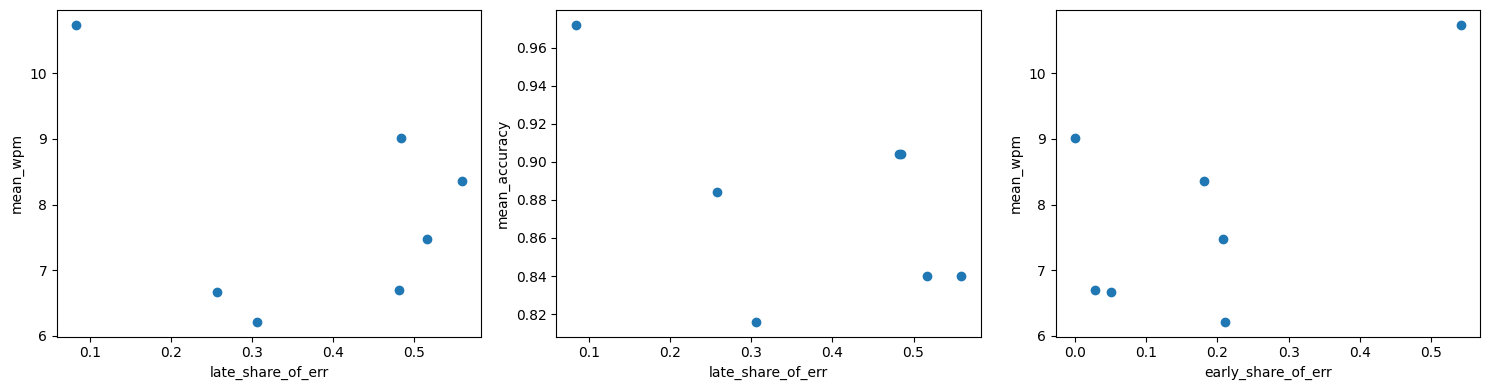

In [14]:
def safe_corr(df, a, b):
    s = df[[a, b]].dropna()
    if len(s) < 3:
        return np.nan, len(s)
    return s[a].corr(s[b]), len(s)

pairs = [("late_share_of_err", "mean_wpm"),
         ("late_share_of_err", "mean_accuracy"),
         ("early_share_of_err", "mean_wpm"),
         ("early_share_of_err", "mean_accuracy"),
         ("mean_trigger_offset_ms", "mean_wpm"),
         ("error_rate_per_keystroke", "mean_wpm")]
pairs = [(a, b) for a, b in pairs
         if a in day_metrics.columns and b in day_metrics.columns]

print("Pearson r across (participant, day) points:")
for a, b in pairs:
    r, n = safe_corr(day_metrics, a, b)
    print(f"  {a:28s} vs {b:16s}  r = {r:.3f}  (n={n})")

if pairs and len(day_metrics) >= 3:
    fig, axes = plt.subplots(1, min(3, len(pairs)),
                             figsize=(5 * min(3, len(pairs)), 4))
    if min(3, len(pairs)) == 1:
        axes = [axes]
    for (a, b), ax in zip(pairs[:3], axes):
        s = day_metrics[[a, b]].dropna()
        ax.scatter(s[a], s[b])
        ax.set_xlabel(a); ax.set_ylabel(b)
    plt.tight_layout(); plt.savefig(OUT_DIR / "rq3_scatter.png", dpi=150); plt.show()


## 8. Export aggregated tables

Saved under `analysis_output/` for the report.

In [15]:
if len(perf):
    perf.to_csv(OUT_DIR / "trial_performance.csv", index=False)
if len(selections):
    selections.to_csv(OUT_DIR / "selection_events.csv", index=False)
if len(session_metrics):
    session_metrics.to_csv(OUT_DIR / "session_metrics.csv", index=False)
if len(day_metrics):
    day_metrics.to_csv(OUT_DIR / "day_metrics.csv", index=False)

print("Wrote to", OUT_DIR.resolve())
for f in sorted(OUT_DIR.glob("*")):
    print("  ", f.name)


Wrote to /Users/yejipark/Documents/GitHub/Gaze_experiments/analysis/analysis_output
   day_metrics.csv
   early_late_by_day.png
   learning_curves.png
   rq3_scatter.png
   selection_events.csv
   session_metrics.csv
   trial_performance.csv
   trigger_offset_bar_by_day.png
   trigger_offset_box_by_day.png
   trigger_offset_by_day.png
   trigger_offset_hist_by_day.png
